**Тема:** Детекція об’єктів.

**Мета:** навчитись вирішувати задачу детектування об’єктів.

                    **Варіант 1**
**Завдання**
Завдання 3-го рівня складності
Реалізувати детекцію об’єктів за допомогою мережі, вказаної у списку. Датасети для
виконання завдань можна обирати самому, наприклад з [2] чи [3].
1. [OverFeat]
2. [DeepID-Net]
3. [R-FCN]
4. [ION]
5. [MultiPathNet]
6. [NoC]
7. [G-RMI]
8. [TDM]
9. [SSD]
10. [DSSD]
11. [YOLOv1]
12. [YOLOv2 / YOLO9000]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import random_split

import xml.etree.ElementTree as ET
import numpy as np
from PIL import Image
from tqdm import tqdm
import copy
import random

from sklearn.metrics import confusion_matrix
from sklearn.metrics import average_precision_score
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import matplotlib.patches as patches


VOC_CLASSES = ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
               'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']
class_to_idx = {cls: idx for idx, cls in enumerate(VOC_CLASSES)}

In [ ]:
class VOCDataset(Dataset):
    def __init__(self, root, year='2007', image_set='trainval', transform=None):
        self.dataset = datasets.VOCDetection(root=root, year=year, image_set=image_set, download=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, target = self.dataset[idx]
        width = int(target['annotation']['size']['width'])
        height = int(target['annotation']['size']['height'])

        obj = target['annotation']['object']
        if isinstance(obj, list):
            obj = obj[0]
        label_name = obj['name'].lower().strip()
        label = class_to_idx.get(label_name, -1)
        bndbox = obj['bndbox']
        xmin = float(bndbox['xmin'])
        ymin = float(bndbox['ymin'])
        xmax = float(bndbox['xmax'])
        ymax = float(bndbox['ymax'])
        bbox = [xmin / width, ymin / height, xmax / width, ymax / height]
        bbox = torch.tensor(bbox, dtype=torch.float32)

        if self.transform is not None:
            img = self.transform(img)

        return img, label, bbox

Fast model

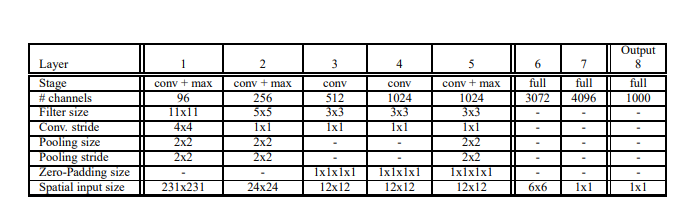

In [ ]:
class OverFeatMultiTask(nn.Module):
    def __init__(self, num_classes=20):
        super(OverFeatMultiTask, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.flatten_dim = 1024 * 7 * 7
        self.fc_shared = nn.Sequential(
            nn.Linear(self.flatten_dim, 3072),
            nn.ReLU(inplace=True)
        )
        self.fc_class = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(3072, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes)
        )
        self.fc_bbox = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(3072, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        shared = self.fc_shared(x)
        class_out = self.fc_class(shared)
        bbox_out = self.fc_bbox(shared)
        return class_out, bbox_out

Accurate model

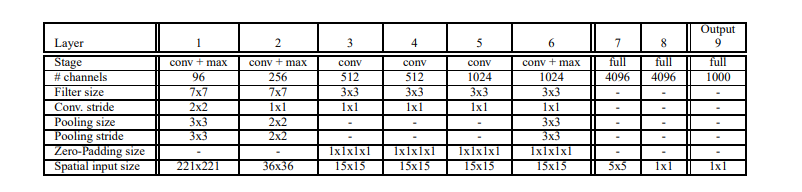

In [ ]:
class OverFeatMultiTask(nn.Module):
    def __init__(self, num_classes=20):
        super(OverFeatMultiTask, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=7, stride=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=3),
            nn.Conv2d(96, 256, kernel_size=7, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=3)
        )
        self.flatten_dim = 1024 * 5 * 5
        self.fc_shared = nn.Sequential(
            nn.Linear(self.flatten_dim, 4096),
            nn.ReLU()
        )
        self.fc_class = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(4096, num_classes)
        )
        self.fc_bbox = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(4096, 4),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        shared = self.fc_shared(x)
        class_out = self.fc_class(shared)
        bbox_out = self.fc_bbox(shared)
        return class_out, bbox_out

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model = None

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
            self.counter = 0
            if self.verbose:
                print("Validation loss decreased, saving model ...")
        else:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

In [ ]:
def visualize_predictions(model, dataloader, device, num_images=5, img_size=231):
    model.eval()
    images, labels, bboxes = next(iter(dataloader))
    images = images[:num_images].to(device)
    labels = labels[:num_images]
    bboxes = bboxes[:num_images]

    with torch.no_grad():
        outputs_cls, outputs_bbox = model(images)
        _, preds = torch.max(outputs_cls, 1)

    images = images.cpu()
    preds = preds.cpu()
    outputs_bbox = outputs_bbox.cpu()
    bboxes = bboxes.cpu()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    images = images * std + mean
    images = images.permute(0, 2, 3, 1).numpy()

    fig, axes = plt.subplots(1, num_images, figsize=(20, 5))
    for i in range(num_images):
        ax = axes[i] if num_images > 1 else axes
        img = images[i]
        ax.imshow(img)

        gt_bbox = bboxes[i].numpy()
        gt_label = labels[i].item()
        gt_class_name = VOC_CLASSES[gt_label]
        rect_gt = patches.Rectangle(
            (gt_bbox[0] * img_size, gt_bbox[1] * img_size),
            (gt_bbox[2] - gt_bbox[0]) * img_size,
            (gt_bbox[3] - gt_bbox[1]) * img_size,
            linewidth=2, edgecolor='g', facecolor='none'
        )

        ax.add_patch(rect_gt)
        ax.text(gt_bbox[0] * img_size, gt_bbox[1] * img_size, f'GT: {gt_class_name}',
                color='g', fontsize=12, bbox=dict(facecolor='g', alpha=0.5))

        pred_bbox = outputs_bbox[i].numpy()
        pred_label = preds[i].item()
        pred_class_name = VOC_CLASSES[pred_label]
        rect_pred = patches.Rectangle(
            (pred_bbox[0] * img_size, pred_bbox[1] * img_size),
            (pred_bbox[2] - pred_bbox[0]) * img_size,
            (pred_bbox[3] - pred_bbox[1]) * img_size,
            linewidth=2, edgecolor='r', facecolor='none'
        )
        ax.add_patch(rect_pred)
        ax.text(pred_bbox[0] * img_size, pred_bbox[1] * img_size, f'Pred: {pred_class_name}',
                color='r', fontsize=12, bbox=dict(facecolor='r', alpha=0.5))

        ax.axis('off')

    plt.show()


def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('Real')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


def top_k_error(outputs, labels, k=5):
    _, top_k_preds = torch.topk(outputs, k, dim=1)
    correct = top_k_preds.eq(labels.view(-1, 1).expand_as(top_k_preds))
    correct_k = correct[:, :k].any(dim=1).float().sum(0)
    return 1 - (correct_k / labels.size(0))


def compute_iou(box1, box2):
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2

    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)

    inter_area = max(0, inter_x_max - inter_x_min) * max(0, inter_y_max - inter_y_min)
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)

    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0


def compute_map(detections, annotations, iou_threshold=0.5):
    aps = []
    for det, ann in zip(detections, annotations):
        detected = [False] * len(det)
        true_positive = 0
        false_positive = 0
        for a in ann:
            matched = False
            for d in det:
                iou = compute_iou(d[:4], a)
                if iou >= iou_threshold:
                    true_positive += 1
                    matched = True
                    break
            if not matched:
                false_positive += 1
        precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
        recall = true_positive / len(ann) if len(ann) > 0 else 0
        aps.append(precision * recall)

    return np.mean(aps)

In [ ]:
def train_model(model, dataloader, criterion_cls, criterion_bbox, optimizer, device, lambda_bbox=1.0):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    for inputs, labels, bboxes in tqdm(dataloader, leave=False):
        inputs = inputs.to(device)
        labels = labels.to(device)
        bboxes = bboxes.to(device)

        optimizer.zero_grad()
        outputs_cls, outputs_bbox = model(inputs)

        loss_cls = criterion_cls(outputs_cls, labels)
        loss_bbox = criterion_bbox(outputs_bbox, bboxes)
        loss = loss_cls + lambda_bbox * loss_bbox

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs_cls, 1)
        running_corrects += torch.sum(preds == labels).item()
        total_samples += inputs.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples
    return epoch_loss, epoch_acc

In [ ]:
def evaluate_model(model, dataloader, criterion_cls, criterion_bbox, device, lambda_bbox=1.0, is_test=False):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    if is_test:
        running_top5_error = 0.0
        running_iou = 0.0
        all_preds = []
        all_labels = []
        all_detections = []
        all_annotations = []

    with torch.no_grad():
        for inputs, labels, bboxes in tqdm(dataloader, leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)
            bboxes = bboxes.to(device)

            outputs_cls, outputs_bbox = model(inputs)

            loss_cls = criterion_cls(outputs_cls, labels)
            loss_bbox = criterion_bbox(outputs_bbox, bboxes)
            loss = loss_cls + lambda_bbox * loss_bbox

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs_cls, 1)
            running_corrects += torch.sum(preds == labels).item()
            total_samples += inputs.size(0)

            if is_test:
                running_top5_error += top_k_error(outputs_cls, labels, k=5).item() * inputs.size(0)
                for i in range(inputs.size(0)):
                    pred_box = outputs_bbox[i].detach().cpu().numpy()
                    gt_box = bboxes[i].detach().cpu().numpy()
                    running_iou += compute_iou(pred_box, gt_box)

                    pred_box_tensor = outputs_bbox[i].unsqueeze(0)
                    pred_score = torch.softmax(outputs_cls[i], dim=0).max().unsqueeze(0)
                    pred_label = preds[i].unsqueeze(0)
                    gt_box_tensor = bboxes[i].unsqueeze(0)
                    gt_label = labels[i].unsqueeze(0)

                    score = pred_score.item()
                    detection = list(pred_box) + [score]  # [x_min, y_min, x_max, y_max, score]
                    annotation = list(gt_box)  # [x_min, y_min, x_max, y_max]
                    all_detections.append([detection])
                    all_annotations.append([annotation])

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples

    if is_test:
        epoch_top1_error = 1 - epoch_acc
        epoch_top5_error = running_top5_error / total_samples
        epoch_iou = running_iou / total_samples
        cm = confusion_matrix(all_labels, all_preds)
        custom_map = compute_map(all_detections, all_annotations)
        return epoch_loss, epoch_acc, epoch_top1_error, epoch_top5_error, epoch_iou, cm, custom_map
    else:
        return epoch_loss, epoch_acc

In [ ]:
def visualize_samples(dataset, num_samples=6):
    fig, axes = plt.subplots(2, num_samples // 2, figsize=(15, 6))
    axes = axes.ravel()

    for i in range(num_samples):
        idx = random.randint(0, len(dataset) - 1)
        img, label, bbox = dataset[idx]

        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        ax = axes[i]
        ax.imshow(img)
        ax.set_title(f"Class: {VOC_CLASSES[label]}")

        h, w, _ = img.shape
        xmin, ymin, xmax, ymax = bbox * torch.tensor([w, h, w, h])
        rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, edgecolor='red', linewidth=2, fill=False)
        ax.add_patch(rect)

        ax.axis("off")

    plt.show()


def plot_class_distribution(dataset):
    labels = [dataset[i][1] for i in range(len(dataset))]
    plt.figure(figsize=(10, 5))
    plt.hist(labels, bins=np.arange(len(class_to_idx)+1)-0.5, rwidth=0.8, alpha=0.7)
    plt.xticks(range(len(class_to_idx)), list(class_to_idx.keys()), rotation=45)
    plt.xlabel("Клас")
    plt.ylabel("Кількість зображень")
    plt.title("Розподіл класів у датасеті")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

In [ ]:
num_classes = len(VOC_CLASSES)
num_epochs = 50
batch_size = 64
learning_rate = 1e-3
lambda_bbox = 1.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
        transforms.Resize((221, 221)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_trainval_dataset = VOCDataset(root='./VOCdevkit', year='2007', image_set='trainval', transform=transform)
train_size = int(0.8 * len(full_trainval_dataset))  # 80% на train
val_size = len(full_trainval_dataset) - train_size  # 20% на val
train_dataset, val_dataset = random_split(full_trainval_dataset, [train_size, val_size])
test_dataset = VOCDataset(root='./VOCdevkit', year='2007', image_set='test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

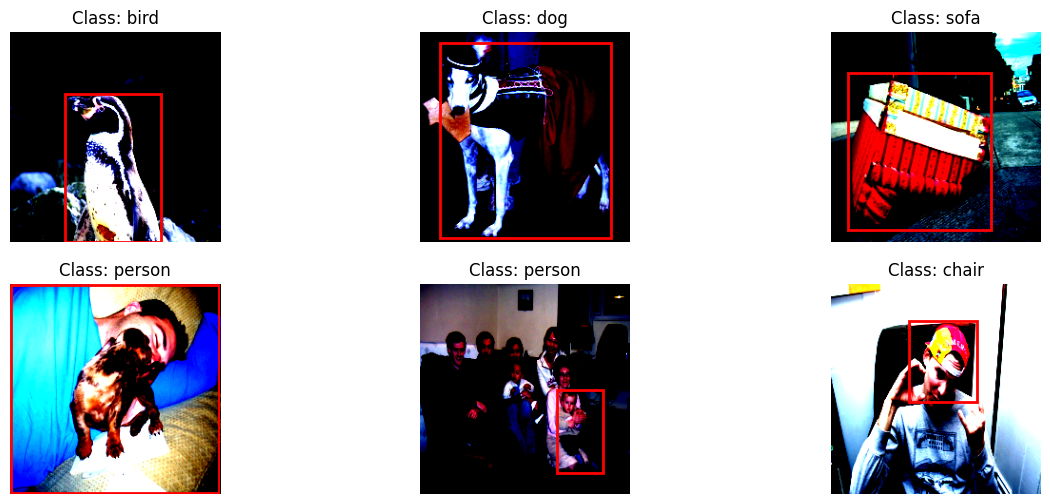

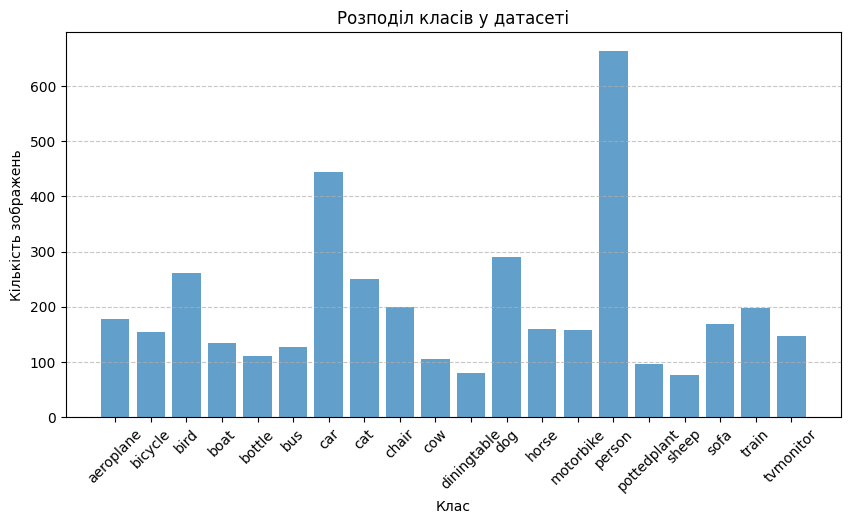

In [ ]:
visualize_samples(train_dataset)
plot_class_distribution(train_dataset)

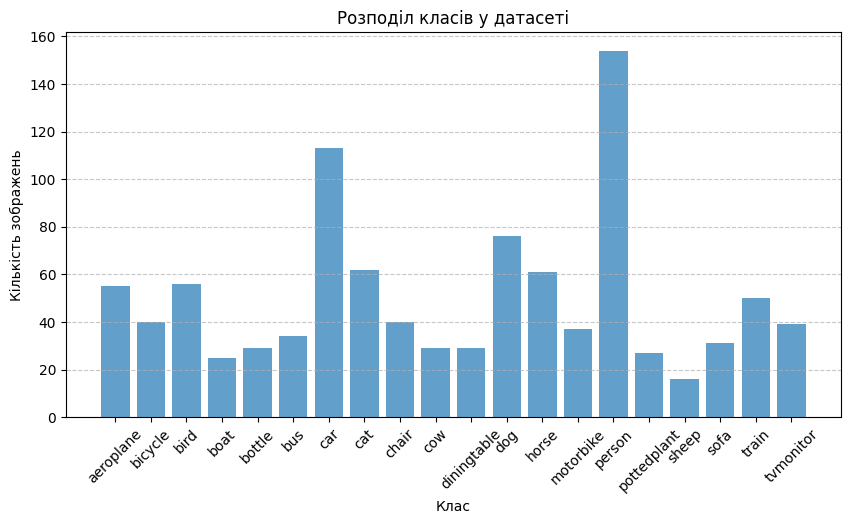

In [ ]:
plot_class_distribution(val_dataset)

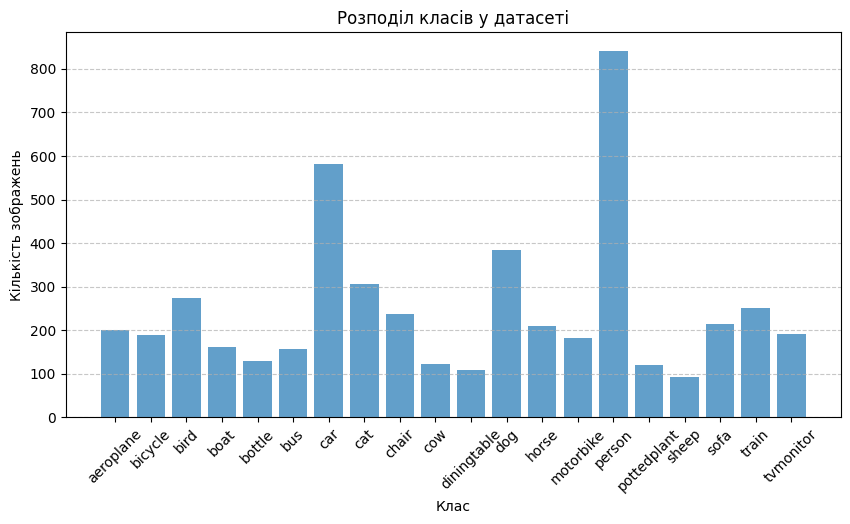

In [ ]:
plot_class_distribution(test_dataset)

In [ ]:
train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]

classes = np.unique(train_labels)

weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_labels)

class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print("Ваги класів:", class_weights)

Ваги класів: tensor([1.1258, 1.3013, 0.7649, 1.4955, 1.8054, 1.5656, 0.4503, 0.7984, 1.0070,
        1.9086, 2.5050, 0.6887, 1.2604, 1.2684, 0.3018, 2.0660, 2.6026, 1.1858,
        1.0121, 1.3541], device='cuda:0')


In [ ]:
class_weights.shape

torch.Size([20])

In [ ]:
model = OverFeatMultiTask(num_classes=num_classes).to(device)
criterion_cls = nn.CrossEntropyLoss()
criterion_bbox = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-4)

Епоха 1/50
Train loss: 4.7624 | Train accuracy: 0.1500
Validation loss: 2.8916 | Validation accuracy: 0.1535 | Validation mAP: 0.1874
Validation loss decreased, saving model ...




Епоха 2/50
Train loss: 2.8505 | Train accuracy: 0.1702
Validation loss: 2.8103 | Validation accuracy: 0.1745 | Validation mAP: 0.0778
Validation loss decreased, saving model ...




Епоха 3/50
Train loss: 2.7840 | Train accuracy: 0.1781
Validation loss: 2.7821 | Validation accuracy: 0.1874 | Validation mAP: 0.0768
Validation loss decreased, saving model ...




Епоха 4/50
Train loss: 2.7352 | Train accuracy: 0.1866
Validation loss: 2.8057 | Validation accuracy: 0.1765 | Validation mAP: 0.1107
EarlyStopping counter: 1 out of 15




Епоха 5/50
Train loss: 2.7342 | Train accuracy: 0.1856
Validation loss: 2.7808 | Validation accuracy: 0.1825 | Validation mAP: 0.1097
Validation loss decreased, saving model ...




...

Епоха 34/50
Train loss: 2.0616 | Train accuracy: 0.3418
Validation loss: 2.4652 | Validation accuracy: 0.2612 | Validation mAP: 0.1974
EarlyStopping counter: 11 out of 15




Епоха 35/50
Train loss: 2.0684 | Train accuracy: 0.3433
Validation loss: 2.5757 | Validation accuracy: 0.2383 | Validation mAP: 0.1067
EarlyStopping counter: 12 out of 15




Епоха 36/50
Train loss: 2.1010 | Train accuracy: 0.3383
Validation loss: 2.4536 | Validation accuracy: 0.2662 | Validation mAP: 0.1605
EarlyStopping counter: 13 out of 15




Епоха 37/50
Train loss: 2.0627 | Train accuracy: 0.3446
Validation loss: 2.4228 | Validation accuracy: 0.2792 | Validation mAP: 0.1805
EarlyStopping counter: 14 out of 15




Епоха 38/50
Train loss: 2.0695 | Train accuracy: 0.3393
Validation loss: 2.4619 | Validation accuracy: 0.2802 | Validation mAP: 0.1635
EarlyStopping counter: 15 out of 15


Early_stopping


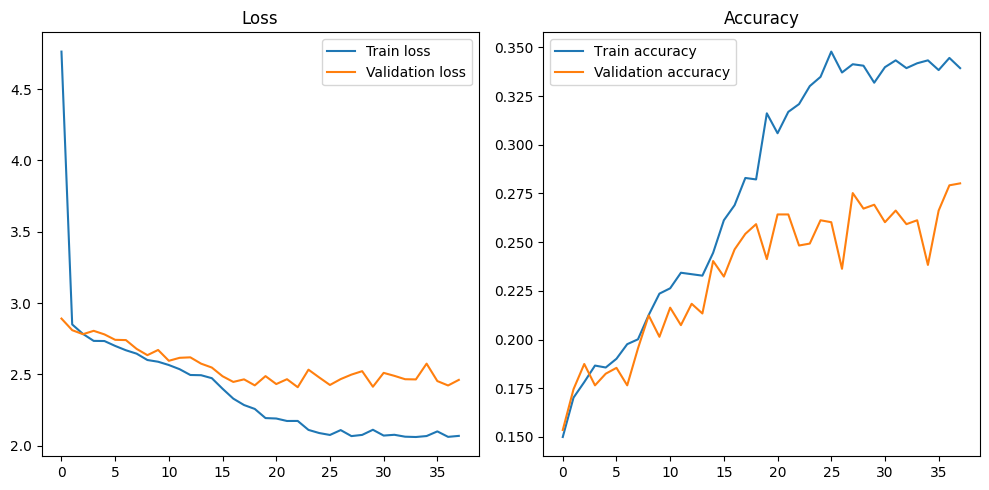

In [ ]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []
early_stopping = EarlyStopping(patience=15, verbose=True)

for epoch in range(num_epochs):
    train_loss, train_acc = train_model(
            model, train_loader, criterion_cls, criterion_bbox, optimizer, device, lambda_bbox
    )
    val_loss, val_acc, val_top1_error, val_top5_error, val_iou, cm, val_map = evaluate_model(
            model, val_loader, criterion_cls, criterion_bbox, device, lambda_bbox, is_test=True
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Епоха {epoch+1}/{num_epochs}")
    print(f"Train loss: {train_loss:.4f} | Train accuracy: {train_acc:.4f}")
    print(f"Validation loss: {val_loss:.4f} | Validation accuracy: {val_acc:.4f} | Validation mAP: {val_map:.4f}")

    early_stopping(val_loss, model)
    print("\n")
    if early_stopping.early_stop:
        print("Early_stopping")
        break

    model.load_state_dict(early_stopping.best_model)


torch.save(model.state_dict(), 'overfeat_multitask_voc.pth')

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Тrain accuracy')
plt.plot(val_accs, label='Validation accuracy')
plt.legend()
plt.title('Accuracy')

plt.tight_layout()
plt.show()

Test loss: 2.4045 | Test accuracy: 0.2712
Test Top-1 error rate: 0.7288 | Test Top-5 error rate: 0.3033
Test IoU: 0.2882 | Test mAP: 0.1529


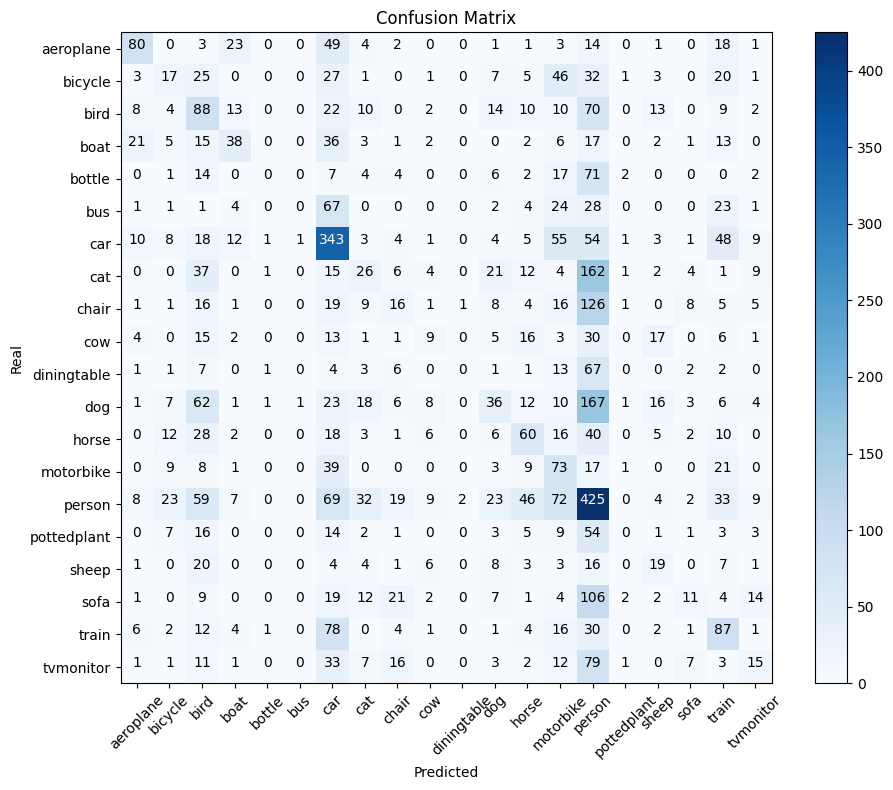

In [ ]:
model = OverFeatMultiTask(num_classes=num_classes).to(device)
model.load_state_dict(torch.load('/content/overfeat_multitask_voc.pth', weights_only=True))

test_loss, test_acc, test_top1_error, test_top5_error, test_iou, cm, map_value = evaluate_model(
        model, test_loader, criterion_cls, criterion_bbox, device, lambda_bbox, is_test=True
)

print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")
print(f"Test Top-1 error rate: {test_top1_error:.4f} | Test Top-5 error rate: {test_top5_error:.4f}")
print(f"Test IoU: {test_iou:.4f} | Test mAP: {map_value:.4f}")
plot_confusion_matrix(cm, classes=VOC_CLASSES)

Візуалізація передбачення

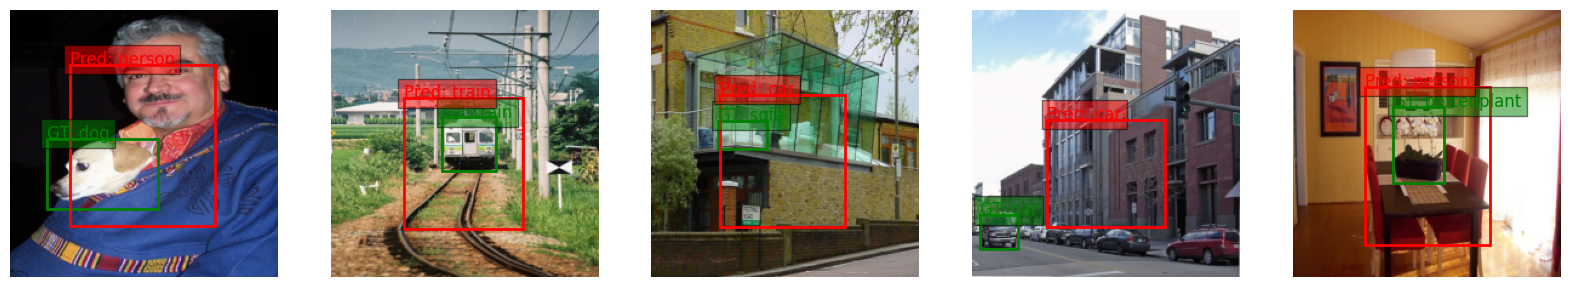

In [ ]:
visualize_predictions(model, test_loader, device, num_images=5, img_size=221)

**Висновок:** У ході лабораторної роботи була проведена тренування моделі для виявлення об'єктів на основі набору даних VOC 2007. Модель була навчена з використанням метрики середньої точності (mAP), а також оцінювання ефективності через тренувальні та валідаційні втрати і точність. В ході тренування було досягнуто певних покращень у точності, однак процес не був безперервно лінійним, а метрики показували різноманітні коливання. Протягом перших декількох епох (1-5) відзначалися значні втрати та низька точність, що є нормальним для початкових етапів тренування. Однак поступово модель почала покращувати свої результати, що стало очевидним зниженням втрат на валідаційних даних, хоча точність і середній показник mAP залишалися низькими до епохи 15. Найбільші покращення спостерігались між епохами 15 та 37, коли модель досягала кращих результатів з точки зору точності та mAP, при цьому втрата на валідації стабільно знижувалась. Загалом, на етапі 38 епохи тренування відбулося раннє припинення (EarlyStopping), оскільки модель показала стабільність показників і подальше покращення стало незначним. Моделювання і тренування показали ефективність застосування глибоких нейронних мереж для виявлення об'єктів у зображеннях, але також вказали на необхідність додаткової оптимізації та налаштування для досягнення ще вищої точності і стабільності на нових даних.